In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce RTX 2050


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device {device}')

Using device cuda


In [5]:
df = pd.read_csv('fashion-mnist_train.csv')
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


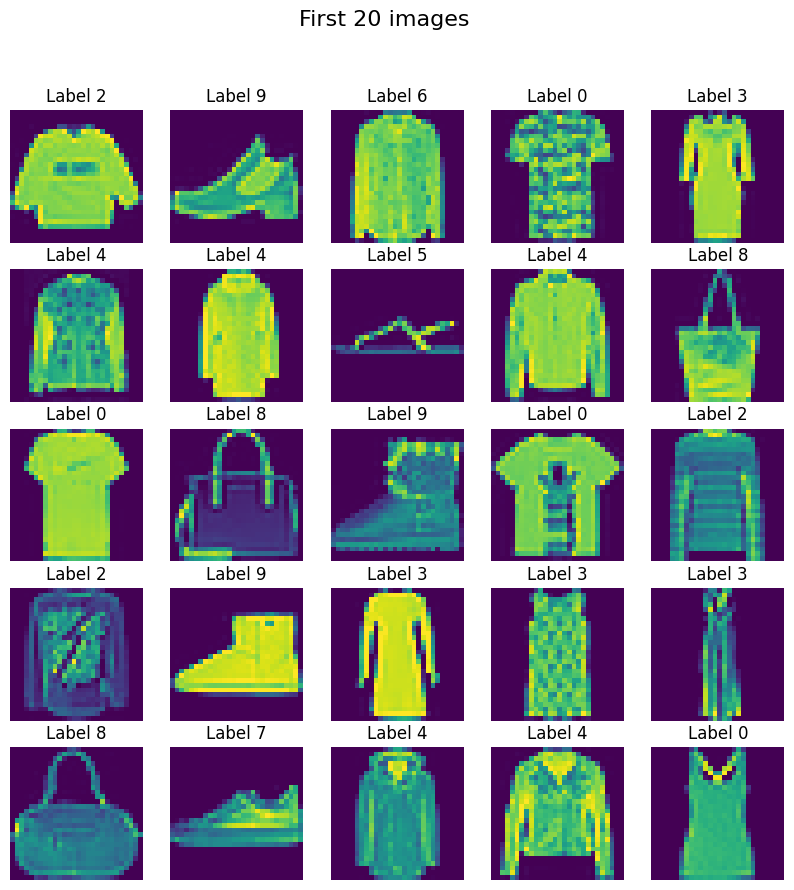

In [6]:
# let's see the images
# basic graph
fig , axes = plt.subplots(5,5, figsize = (10,10))
fig.suptitle('First 20 images', fontsize=16)

for i,ax in enumerate(axes.flat):  # enumerate returns name with index
    img = df.iloc[i , 1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    
    ax.set_title(f'Label {df.iloc[i,0]}')

In [7]:
# input layer 
print(len(df.columns) )  # 784 cz label bad

# output layer depends on unique labels
print(len(df['label'].unique()))

785
10


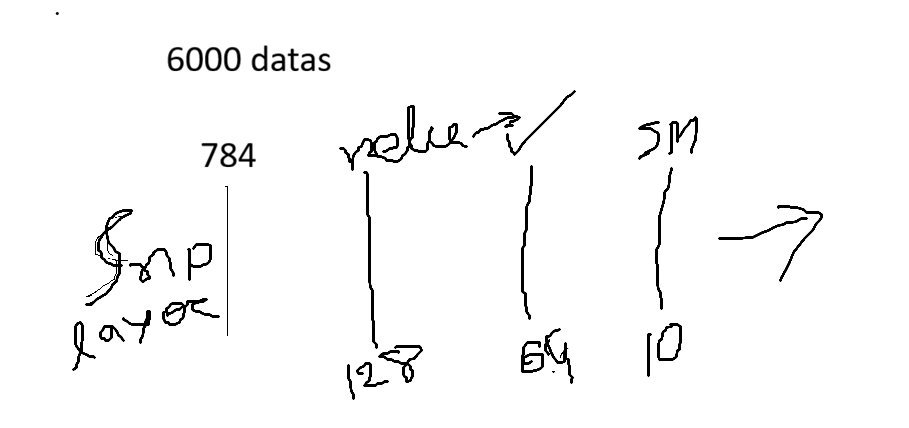

In [8]:
# train test split
x = df.iloc[: , 1:].values
y = df.iloc[: , 0].values

x_train , x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)

In [9]:
# scaling the features 
x_train = x_train/255.0 # 255 is max pixel
x_test = x_test/255.0

In [10]:
# custom dataset
class CustomDataSet(Dataset):
    def __init__(self,features , labels):
        self.features = torch.tensor(features, dtype=torch.float32) # transformation
        self.labels = torch.tensor(labels, dtype=torch.long) # transformation
        
    def __len__(self):
        return len(self.features) 
    
    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [11]:
train_dataset = CustomDataSet(x_train, y_train)
test_dataset = CustomDataSet(x_test, y_test)

In [12]:
# Dataloader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)


### Defining nn class

In [13]:
class MyNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(num_features,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64,10),

        )
    def forward(self,x):
        return self.model(x)
    
    

#### Instantiate model

In [14]:
epochs = 10
learning_rate = 0.1

model = MyNN(x_train.shape[1])
model = model.to(device) # model gpu te run koracchi

In [15]:
# loss function 
criterion = nn.CrossEntropyLoss()

In [16]:
# optimizer
optimizer = optim.SGD(model.parameters(),learning_rate)

In [17]:
# training loop
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features , batch_labels in train_loader:
        
        # move data to gpu
        batch_features,batch_labels = batch_features.to(device), batch_labels.to(device)
        # forward pass
        y_pred = model(batch_features)
        # calc loss
        loss = criterion(y_pred, batch_labels)
        #back pass
        optimizer.zero_grad()
        loss.backward()
        
        # update
        optimizer.step()
        
        # print(loss.item())
        total_epoch_loss = total_epoch_loss + loss.item()

avg_loss = total_epoch_loss/len(train_loader)
avg_loss

0.24232942187289397

### Evaluation

In [18]:
model.eval()

total = 0
correct = 0


with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    batch_features,batch_labels = batch_features.to(device), batch_labels.to(device)
    y_pred = model(batch_features)
  
    _,predicted = torch.max(y_pred,1)  # rturns maxVal and indices(class prediction), _ recieves the max val that i dont need


    #total
    total = total + batch_labels.shape[0]

    correct = correct + (predicted==batch_labels).sum().item()


print(correct/total)
# print(f"total number {total}")
# print(f"correct {correct}")

0.8893333333333333
